#Практична робота №6

##**Тема. Графи. Найкоротші шляхи**
##**Мета**: набути практичних навичок розв’язання задач пошуку найкоротших шляхів у графі та оцінювання їх асимптотичної складності.
##**Виконав:** Рафієв Б.

###**Завдання для самостійного розв’язання**

**Умова:** Задано зважений неорієнтований граф який містить 6 вершин. Необхідно знайти найкоротші шляхи від вершини 1 до всіх інших вершин графа за допомогою алгоритму Флойда–Воршалла, реалізувати його мовою Python та оцінити складність.  
**1. Матриця суміжності (ваг) вихідного графа** Аналізуючи граф, випишемо всі вершини та ваги ребер між ними (оскільки граф неорієнтований, матриця є симетричною, а відсутні ребра позначаємо як нескінченність $\infty$):  
Ребра: $(1,2)=7$, $(1,3)=3$, $(1,4)=1$, $(3,4)=7$, $(3,5)=11$, $(4,5)=5$, $(4,6)=4$, $(4,2)=2$, $(5,6)=6$, $(6,2)=8$.  
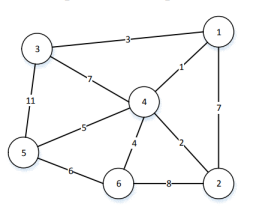  
**2. Реалізація алгоритму Флойда–Воршалла на Python** Алгоритм Флойда–Воршалла розраховує найкоротші відстані між усіма парами вершин, поступово перебираючи кожну вершину $k$ як можливий транзитний (проміжний) пункт.  

In [1]:
import math

def floyd_warshall(vertices, edges):
    n = len(vertices)

    v_to_idx = {v: i for i, v in enumerate(vertices)}
    idx_to_v = {i: v for i, v in enumerate(vertices)}

    dist = [[math.inf] * n for _ in range(n)]

    for i in range(n):
        dist[i][i] = 0

    for u, v, w in edges:
        i, j = v_to_idx[u], v_to_idx[v]
        dist[i][j] = w
        dist[j][i] = w 

    for k in range(n):      
        for i in range(n):  
            for j in range(n):
                if dist[i][k] + dist[k][j] < dist[i][j]:
                    dist[i][j] = dist[i][k] + dist[k][j]
                    
    return dist, v_to_idx

vertices_list = [1, 2, 3, 4, 5, 6]
edges_list = [
    (1, 2, 7), (1, 3, 3), (1, 4, 1),
    (3, 4, 7), (3, 5, 11),
    (4, 5, 5), (4, 6, 4), (4, 2, 2),
    (5, 6, 6), (6, 2, 8)
]

matrix, mapping = floyd_warshall(vertices_list, edges_list)

start_vertex = 1
start_idx = mapping[start_vertex]

print(f"--- Найкоротші відстані від вершини {start_vertex} до інших ---")
for v in vertices_list:
    target_idx = mapping[v]
    print(f"Шлях {start_vertex} -> {v}: Відстань = {matrix[start_idx][target_idx]}")

--- Найкоротші відстані від вершини 1 до інших ---
Шлях 1 -> 1: Відстань = 0
Шлях 1 -> 2: Відстань = 3
Шлях 1 -> 3: Відстань = 3
Шлях 1 -> 4: Відстань = 1
Шлях 1 -> 5: Відстань = 6
Шлях 1 -> 6: Відстань = 5


**Аналітична перевірка маршрутів:**  
До 2: через вершину 4 ($1 \rightarrow 4 \rightarrow 2$) разом: $1 + 2 = 3$ (коротше, ніж пряме ребро $7$).  
До 3: пряме ребро = $3$.До 4: пряме ребро = $1$.  
До 5: через вершину 4 ($1 \rightarrow 4 \rightarrow 5$) разом: $1 + 5 = 6$.  
До 6: через вершину 4 ($1 \rightarrow 4 \rightarrow 6$) разом: $1 + 4 = 5$.

###**Висновок:** під час виконання цієї практичної роботи я набув практичних навичок розв’язання задач пошуку найкоротших шляхів у графі та оцінювання їх асимптотичної складності.  
###Контрольні питання:
1. Граф — це абстрактна математична структура та модель, яка використовується для відображення зв'язків між об'єктами, де головними складовими елементами структури є множина вершин (або вузлів) $V$, які уособлюють самі об'єкти, та множина ребер (або дуг) $E$, що з'єднують ці вершини між собою. Залежно від наявності визначеного напрямку руху ребра можуть бути орієнтованими чи неорієнтованими, а для відображення вартості чи довжини переходу їм часто присвоюють третій компонент — числовий показник ваги.
2. Для розв'язання цієї задачі, залежно від її специфіки (пошук від одного джерела чи між усіма парами вершин) та властивостей графа, використовують такі класичні алгоритми, як алгоритм Дейкстри для графів без ребер з від'ємною вагою, алгоритм Белмана–Форда для універсального пошуку в умовах наявності від'ємних ваг, алгоритм Флойда–Воршалла для комплексного знаходження матриці відстаней між усіма парами вузлів одночасно, а також алгоритм А* (A-star) для евристичного прискорення пошуку в просторових та навігаційних задачах.
3. Алгоритм Дейкстри працює за жадібним принципом: він покроково вилучає з черги з пріоритетами вершину з найменшою поточною відстанню від джерела та релаксує всі вихідні ребра, оновлюючи через них найкоротші шляхи до сусідніх вузлів. Головною його особливістю та обмеженням є висока швидкість роботи $O((|V| + |E|) \log V)$ на розріджених графах за умови абсолютної відсутності ребер з від'ємною вагою, оскільки поява від'ємної вартості ламає жадібну логіку та призводить до некоректних результатів.
4. Алгоритм Белмана–Форда — це універсальний алгоритм пошуку найкоротших шляхів від однієї вершини до всіх інших, який ітеративно (рівно $|V| - 1$ разів) перебирає абсолютно всі ребра графа і релаксує відстані до вершин. Його варто застосовувати тоді, коли граф містить ребра з від'ємними вагами, або коли необхідно гарантовано виявити наявність так званого «від'ємного циклу» (циклу, обхід якого нескінченно зменшує довжину шляху), що робить його незамінним у фінансовому моделюванні чи складній мережевій маршрутизації.
5. Алгоритм Флойда–Воршалла базується на динамічному програмуванні та працює шляхом послідовного потрійного циклу, який оцінює можливість покращення (скорочення) шляху між будь-якою парою вершин $i$ та $j$ через кожну проміжну вершину $k$ графа. Головною перевагою алгоритму є знаходження найкоротших відстаней відразу між усіма парами вершин за допомогою дуже простого у реалізації коду, що допускає від'ємні ваги, а ключовими недоліками є висока кубічна часова складність $O(|V|^3)$ та значні витрати пам'яті $O(|V|^2)$, що обмежує його використання виключно невеликими за розміром графами.